# Optimización de Modelos de Machine Learning

Este notebook implementa **técnicas de optimización especializadas** para acelerar el entrenamiento y predicción de modelos ML sin perder capacidad predictiva.

---

##  Objetivo

Comparar el desempeño de diferentes técnicas de optimización por modelo:

| Modelo | Técnica de Optimización |
|--------|-------------------------|
| **KNN** | KD-Trees, Ball Trees, FAISS |
| **Ridge/Lasso** | Solver optimizado: saga |
| **Naive Bayes** | `partial_fit()` con entrenamiento por lotes |
| **XGBoost** | `tree_method='hist'`, `early_stopping_rounds` |
| **SVM** | SGDClassifier, LinearSVC |

---

##  Datos

Se utilizan los **datos preprocesados** de `data/processed/`:
-  Ya escalados con StandardScaler
-  Ya codificados (One-Hot Encoding)
-  Train balanceado con SMOTE
-  Sin valores faltantes

---

##  Métricas Evaluadas

- **Tiempo de entrenamiento** (segundos)
- **Uso de memoria** (MB)
- **Accuracy** en validación
- **Velocidad de predicción** (muestras/segundo)

In [39]:
# =========================================
# 1. Importar librerías necesarias
# =========================================

import time
import psutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Modelos de clasificación
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

# Métricas y utilidades
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_palette("pastel")

print(" Librerías importadas correctamente")

 Librerías importadas correctamente


In [40]:
# =========================================
# 2. Cargar datos preprocesados
# =========================================

print("📂 Cargando datos procesados de 'data/processed/'...\n")

# Cargar datos de entrenamiento (BALANCEADOS con SMOTE)
X_train = pd.read_csv('data/processed/X_train.csv')
y_train = pd.read_csv('data/processed/y_train.csv').values.ravel()

# Cargar datos de validación (SIN balancear)
X_val = pd.read_csv('data/processed/X_val.csv')
y_val = pd.read_csv('data/processed/y_val.csv').values.ravel()

# Cargar datos de test (SIN balancear)
X_test = pd.read_csv('data/processed/X_test.csv')
y_test = pd.read_csv('data/processed/y_test.csv').values.ravel()

print(" Datos cargados exitosamente\n")

# Información de los datos
print("="*60)
print(" "*15 + "INFORMACIÓN DE LOS DATOS")
print("="*60)
print(f"\n DIMENSIONES:")
print(f"  Train:      {X_train.shape[0]:>7,} muestras × {X_train.shape[1]:>3} features")
print(f"  Validation: {X_val.shape[0]:>7,} muestras × {X_val.shape[1]:>3} features")
print(f"  Test:       {X_test.shape[0]:>7,} muestras × {X_test.shape[1]:>3} features")

print(f"\n BALANCE DE CLASES (Train - SMOTE aplicado):")
train_counts = pd.Series(y_train).value_counts()
print(f"  Clase 0: {train_counts[0]:>7,} ({train_counts[0]/len(y_train)*100:>5.1f}%)")
print(f"  Clase 1: {train_counts[1]:>7,} ({train_counts[1]/len(y_train)*100:>5.1f}%)")

print("\n" + "="*60)

# Convertir a arrays de NumPy para algunos modelos
X_train_array = X_train.values
X_val_array = X_val.values
X_test_array = X_test.values

📂 Cargando datos procesados de 'data/processed/'...

 Datos cargados exitosamente

               INFORMACIÓN DE LOS DATOS

 DIMENSIONES:
  Train:       71,236 muestras × 113 features
  Validation:  15,265 muestras × 113 features
  Test:        15,265 muestras × 113 features

 BALANCE DE CLASES (Train - SMOTE aplicado):
  Clase 0:  38,405 ( 53.9%)
  Clase 1:  32,831 ( 46.1%)

 Datos cargados exitosamente

               INFORMACIÓN DE LOS DATOS

 DIMENSIONES:
  Train:       71,236 muestras × 113 features
  Validation:  15,265 muestras × 113 features
  Test:        15,265 muestras × 113 features

 BALANCE DE CLASES (Train - SMOTE aplicado):
  Clase 0:  38,405 ( 53.9%)
  Clase 1:  32,831 ( 46.1%)



In [41]:
# =========================================
# 3. Función de evaluación con métricas de optimización
# =========================================

def evaluar_modelo_optimizado(nombre, modelo, X_train, y_train, X_val, y_val, 
                                tecnica, config, train_params=None):
    """
    Evalúa un modelo con técnicas de optimización, midiendo:
    - Tiempo de entrenamiento
    - Uso de memoria
    - Accuracy, F1-score, Precision, Recall
    - Velocidad de predicción
    
    Args:
        nombre: Nombre del modelo
        modelo: Instancia del modelo
        train_params: Diccionario con parámetros adicionales para fit()
    """
    
    print(f"\n{'='*70}")
    print(f"🔧 OPTIMIZANDO: {nombre}")
    print(f"{'='*70}")
    print(f"Técnica: {tecnica}")
    print(f"Config:  {config}")
    
    # Obtener proceso para medir memoria
    process = psutil.Process()
    
    # 1. ENTRENAMIENTO
    memory_before = process.memory_info().rss / (1024 * 1024)  # MB
    start_train = time.time()
    
    if train_params:
        modelo.fit(X_train, y_train, **train_params)
    else:
        modelo.fit(X_train, y_train)
    
    end_train = time.time()
    memory_after = process.memory_info().rss / (1024 * 1024)  # MB
    
    tiempo_entrenamiento = end_train - start_train
    memoria_usada = memory_after - memory_before
    
    print(f"\n⏱️  Tiempo entrenamiento: {tiempo_entrenamiento:.4f}s")
    print(f"💾 Memoria usada: {memoria_usada:.2f} MB")
    
    # 2. PREDICCIÓN Y VELOCIDAD
    start_pred = time.time()
    y_pred = modelo.predict(X_val)
    end_pred = time.time()
    
    tiempo_prediccion = end_pred - start_pred
    # Evitar división por cero
    if tiempo_prediccion > 0:
        velocidad_pred = len(X_val) / tiempo_prediccion  # muestras/segundo
    else:
        velocidad_pred = len(X_val) / 0.0001  # Usar tiempo mínimo de 0.1ms
    
    print(f"⚡ Velocidad predicción: {velocidad_pred:,.0f} muestras/s")
    
    # 3. MÉTRICAS DE DESEMPEÑO
    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    
    print(f"\n Métricas:")
    print(f"   • Accuracy:  {accuracy:.4f}")
    print(f"   • F1-score:  {f1:.4f}")
    print(f"   • Precision: {precision:.4f}")
    print(f"   • Recall:    {recall:.4f}")
    
    return {
        'Modelo': nombre,
        'Técnica': tecnica,
        'Configuración': config,
        'Tiempo Train (s)': round(tiempo_entrenamiento, 4),
        'Memoria (MB)': round(memoria_usada, 2),
        'Velocidad (muestras/s)': int(velocidad_pred),
        'Accuracy': round(accuracy, 4),
        'F1-score': round(f1, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4)
    }

print(" Función de evaluación definida")

 Función de evaluación definida


## **4. Optimización por Modelo**

A continuación se implementan las técnicas de optimización específicas para cada modelo.

### 4.1. K-Nearest Neighbors (KNN)

**Técnicas evaluadas:**
- **KD-Trees:** Estructura de datos para búsqueda rápida en espacios de baja dimensionalidad
- **Ball Trees:** Optimizado para espacios de alta dimensionalidad
- **Brute Force:** Método base sin optimización (para comparación)

In [42]:
# =========================================
# 4.1. KNN - K-Nearest Neighbors
# =========================================

resultados = []

# KNN con Brute Force (sin optimización - baseline)
knn_brute = KNeighborsClassifier(n_neighbors=5, algorithm='brute', n_jobs=-1)
resultado = evaluar_modelo_optimizado(
    nombre="KNN",
    modelo=knn_brute,
    X_train=X_train_array,
    y_train=y_train,
    X_val=X_val_array,
    y_val=y_val,
    tecnica="Brute Force (baseline)",
    config="n_neighbors=5, sin optimización"
)
resultados.append(resultado)

# KNN con KD-Trees
knn_kdtree = KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree', n_jobs=-1)
resultado = evaluar_modelo_optimizado(
    nombre="KNN",
    modelo=knn_kdtree,
    X_train=X_train_array,
    y_train=y_train,
    X_val=X_val_array,
    y_val=y_val,
    tecnica="KD-Trees",
    config="n_neighbors=5, búsqueda optimizada con KD-Tree"
)
resultados.append(resultado)

# KNN con Ball Trees
knn_balltree = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', n_jobs=-1)
resultado = evaluar_modelo_optimizado(
    nombre="KNN",
    modelo=knn_balltree,
    X_train=X_train_array,
    y_train=y_train,
    X_val=X_val_array,
    y_val=y_val,
    tecnica="Ball Trees",
    config="n_neighbors=5, optimizado para alta dimensionalidad"
)
resultados.append(resultado)

print("\n KNN optimizado con 3 técnicas")


🔧 OPTIMIZANDO: KNN
Técnica: Brute Force (baseline)
Config:  n_neighbors=5, sin optimización

⏱️  Tiempo entrenamiento: 0.0749s
💾 Memoria usada: 63.73 MB
⚡ Velocidad predicción: 3,096 muestras/s

 Métricas:
   • Accuracy:  0.5549
   • F1-score:  0.4884
   • Precision: 0.5193
   • Recall:    0.4611

🔧 OPTIMIZANDO: KNN
Técnica: KD-Trees
Config:  n_neighbors=5, búsqueda optimizada con KD-Tree
⚡ Velocidad predicción: 3,096 muestras/s

 Métricas:
   • Accuracy:  0.5549
   • F1-score:  0.4884
   • Precision: 0.5193
   • Recall:    0.4611

🔧 OPTIMIZANDO: KNN
Técnica: KD-Trees
Config:  n_neighbors=5, búsqueda optimizada con KD-Tree

⏱️  Tiempo entrenamiento: 1.7971s
💾 Memoria usada: 70.17 MB

⏱️  Tiempo entrenamiento: 1.7971s
💾 Memoria usada: 70.17 MB
⚡ Velocidad predicción: 387 muestras/s

 Métricas:
   • Accuracy:  0.5549
   • F1-score:  0.4884
   • Precision: 0.5193
   • Recall:    0.4611

🔧 OPTIMIZANDO: KNN
Técnica: Ball Trees
Config:  n_neighbors=5, optimizado para alta dimensionalidad
⚡ 

### 4.2. Naive Bayes

**Técnica evaluada:**
- **partial_fit():** Entrenamiento incremental por lotes, útil para datasets grandes que no caben en memoria

In [43]:
# =========================================
# 4.2. Naive Bayes - GaussianNB
# =========================================

# Naive Bayes con entrenamiento normal (baseline)
nb_normal = GaussianNB()
resultado = evaluar_modelo_optimizado(
    nombre="Naive Bayes",
    modelo=nb_normal,
    X_train=X_train_array,
    y_train=y_train,
    X_val=X_val_array,
    y_val=y_val,
    tecnica="fit() normal (baseline)",
    config="Entrenamiento completo en una sola pasada"
)
resultados.append(resultado)

# Naive Bayes con partial_fit() (entrenamiento por lotes)
print(f"\n{'='*70}")
print(f"🔧 OPTIMIZANDO: Naive Bayes")
print(f"{'='*70}")
print(f"Técnica: partial_fit() con lotes")
print(f"Config:  Entrenamiento incremental, batch_size=1000")

process = psutil.Process()
memory_before = process.memory_info().rss / (1024 * 1024)
start_train = time.time()

# Entrenamiento por lotes
nb_partial = GaussianNB()
batch_size = 1000
n_batches = len(X_train_array) // batch_size + 1

for i in range(0, len(X_train_array), batch_size):
    X_batch = X_train_array[i:i + batch_size]
    y_batch = y_train[i:i + batch_size]
    nb_partial.partial_fit(X_batch, y_batch, classes=np.unique(y_train))

end_train = time.time()
memory_after = process.memory_info().rss / (1024 * 1024)

tiempo_entrenamiento = end_train - start_train
memoria_usada = memory_after - memory_before

print(f"\n⏱️  Tiempo entrenamiento: {tiempo_entrenamiento:.4f}s")
print(f"💾 Memoria usada: {memoria_usada:.2f} MB")
print(f"📦 Lotes procesados: {n_batches}")

# Predicción
start_pred = time.time()
y_pred = nb_partial.predict(X_val_array)
end_pred = time.time()

tiempo_prediccion = end_pred - start_pred
# Evitar división por cero
if tiempo_prediccion > 0:
    velocidad_pred = len(X_val_array) / tiempo_prediccion
else:
    velocidad_pred = len(X_val_array) / 0.0001

print(f"⚡ Velocidad predicción: {velocidad_pred:,.0f} muestras/s")

# Métricas
accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, zero_division=0)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)

print(f"\n Métricas:")
print(f"   • Accuracy:  {accuracy:.4f}")
print(f"   • F1-score:  {f1:.4f}")
print(f"   • Precision: {precision:.4f}")
print(f"   • Recall:    {recall:.4f}")

resultados.append({
    'Modelo': "Naive Bayes",
    'Técnica': "partial_fit() con lotes",
    'Configuración': f"batch_size={batch_size}, {n_batches} lotes",
    'Tiempo Train (s)': round(tiempo_entrenamiento, 4),
    'Memoria (MB)': round(memoria_usada, 2),
    'Velocidad (muestras/s)': int(velocidad_pred),
    'Accuracy': round(accuracy, 4),
    'F1-score': round(f1, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4)
})

print("\n Naive Bayes optimizado con 2 técnicas")


🔧 OPTIMIZANDO: Naive Bayes
Técnica: fit() normal (baseline)
Config:  Entrenamiento completo en una sola pasada

⏱️  Tiempo entrenamiento: 0.2188s
💾 Memoria usada: 0.12 MB
⚡ Velocidad predicción: 397,714 muestras/s

 Métricas:
   • Accuracy:  0.5948
   • F1-score:  0.5006
   • Precision: 0.5794
   • Recall:    0.4407

🔧 OPTIMIZANDO: Naive Bayes
Técnica: partial_fit() con lotes
Config:  Entrenamiento incremental, batch_size=1000

⏱️  Tiempo entrenamiento: 0.2188s
💾 Memoria usada: 0.12 MB
⚡ Velocidad predicción: 397,714 muestras/s

 Métricas:
   • Accuracy:  0.5948
   • F1-score:  0.5006
   • Precision: 0.5794
   • Recall:    0.4407

🔧 OPTIMIZANDO: Naive Bayes
Técnica: partial_fit() con lotes
Config:  Entrenamiento incremental, batch_size=1000

⏱️  Tiempo entrenamiento: 0.2236s
💾 Memoria usada: 0.33 MB
📦 Lotes procesados: 72
⚡ Velocidad predicción: 365,882 muestras/s

 Métricas:
   • Accuracy:  0.5948
   • F1-score:  0.5007
   • Precision: 0.5794
   • Recall:    0.4409

 Naive Bayes opti

### 4.3. Ridge & Lasso

**Técnica evaluada:**
- **Solver 'saga':** Optimizado para datasets grandes, soporta regularización L1 y L2

In [44]:
# =========================================
# 4.3. Ridge - Regularización L2
# =========================================

# Ridge con solver por defecto (baseline)
ridge_default = RidgeClassifier(alpha=1.0, random_state=42)
resultado = evaluar_modelo_optimizado(
    nombre="Ridge",
    modelo=ridge_default,
    X_train=X_train_array,
    y_train=y_train,
    X_val=X_val_array,
    y_val=y_val,
    tecnica="Solver por defecto",
    config="alpha=1.0, solver automático"
)
resultados.append(resultado)

# Ridge con solver 'saga' (optimizado)
ridge_saga = RidgeClassifier(alpha=1.0, solver='saga', max_iter=1000, random_state=42)
resultado = evaluar_modelo_optimizado(
    nombre="Ridge",
    modelo=ridge_saga,
    X_train=X_train_array,
    y_train=y_train,
    X_val=X_val_array,
    y_val=y_val,
    tecnica="Solver 'saga'",
    config="alpha=1.0, solver optimizado para datos grandes"
)
resultados.append(resultado)

print("\n Ridge optimizado con 2 técnicas")


🔧 OPTIMIZANDO: Ridge
Técnica: Solver por defecto
Config:  alpha=1.0, solver automático

⏱️  Tiempo entrenamiento: 0.2109s
⏱️  Tiempo entrenamiento: 0.2109s
💾 Memoria usada: 1.66 MB
⚡ Velocidad predicción: 3,060,226 muestras/s

 Métricas:
   • Accuracy:  0.6244
   • F1-score:  0.5190
   • Precision: 0.6332
   • Recall:    0.4397

🔧 OPTIMIZANDO: Ridge
Técnica: Solver 'saga'
Config:  alpha=1.0, solver optimizado para datos grandes

💾 Memoria usada: 1.66 MB
⚡ Velocidad predicción: 3,060,226 muestras/s

 Métricas:
   • Accuracy:  0.6244
   • F1-score:  0.5190
   • Precision: 0.6332
   • Recall:    0.4397

🔧 OPTIMIZANDO: Ridge
Técnica: Solver 'saga'
Config:  alpha=1.0, solver optimizado para datos grandes

⏱️  Tiempo entrenamiento: 100.1238s
💾 Memoria usada: 0.53 MB
⚡ Velocidad predicción: 2,766,421 muestras/s

 Métricas:
   • Accuracy:  0.6241
   • F1-score:  0.5188
   • Precision: 0.6328
   • Recall:    0.4396

 Ridge optimizado con 2 técnicas

⏱️  Tiempo entrenamiento: 100.1238s
💾 Memori

In [45]:
# =========================================
# 4.4. Lasso - Regularización L1
# =========================================

# Lasso con solver por defecto (baseline)
lasso_default = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
resultado = evaluar_modelo_optimizado(
    nombre="Lasso",
    modelo=lasso_default,
    X_train=X_train_array,
    y_train=y_train,
    X_val=X_val_array,
    y_val=y_val,
    tecnica="Solver 'liblinear'",
    config="penalty='l1', solver estándar"
)
resultados.append(resultado)

# Lasso con solver 'saga' (optimizado)
lasso_saga = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, n_jobs=-1, random_state=42)
resultado = evaluar_modelo_optimizado(
    nombre="Lasso",
    modelo=lasso_saga,
    X_train=X_train_array,
    y_train=y_train,
    X_val=X_val_array,
    y_val=y_val,
    tecnica="Solver 'saga'",
    config="penalty='l1', solver optimizado, paralelizado"
)
resultados.append(resultado)

print("\n Lasso optimizado con 2 técnicas")


🔧 OPTIMIZANDO: Lasso
Técnica: Solver 'liblinear'
Config:  penalty='l1', solver estándar

⏱️  Tiempo entrenamiento: 34.3525s
💾 Memoria usada: -3.41 MB
⚡ Velocidad predicción: 1,602,815 muestras/s

 Métricas:
   • Accuracy:  0.6250
   • F1-score:  0.5226
   • Precision: 0.6322
   • Recall:    0.4454

🔧 OPTIMIZANDO: Lasso
Técnica: Solver 'saga'
Config:  penalty='l1', solver optimizado, paralelizado

⏱️  Tiempo entrenamiento: 34.3525s
💾 Memoria usada: -3.41 MB
⚡ Velocidad predicción: 1,602,815 muestras/s

 Métricas:
   • Accuracy:  0.6250
   • F1-score:  0.5226
   • Precision: 0.6322
   • Recall:    0.4454

🔧 OPTIMIZANDO: Lasso
Técnica: Solver 'saga'
Config:  penalty='l1', solver optimizado, paralelizado

⏱️  Tiempo entrenamiento: 110.1201s
💾 Memoria usada: 3.08 MB
⚡ Velocidad predicción: 3,787,627 muestras/s

 Métricas:
   • Accuracy:  0.6243
   • F1-score:  0.5216
   • Precision: 0.6314
   • Recall:    0.4443

 Lasso optimizado con 2 técnicas

⏱️  Tiempo entrenamiento: 110.1201s
💾 Memor

### 4.4. XGBoost

**Técnicas evaluadas:**
- **tree_method='hist':** Construcción rápida de histogramas para splits
- **early_stopping_rounds:** Detención temprana para evitar sobreajuste y ahorrar tiempo

In [46]:
# =========================================
# 4.5. XGBoost - Extreme Gradient Boosting
# =========================================

# XGBoost con configuración básica (baseline)
xgb_basic = XGBClassifier(
    eval_metric='logloss',
    enable_categorical=False,
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)
resultado = evaluar_modelo_optimizado(
    nombre="XGBoost",
    modelo=xgb_basic,
    X_train=X_train_array,
    y_train=y_train,
    X_val=X_val_array,
    y_val=y_val,
    tecnica="Configuración básica",
    config="n_estimators=100, sin optimizaciones"
)
resultados.append(resultado)

# XGBoost con tree_method='hist' (optimizado)
xgb_hist = XGBClassifier(
    eval_metric='logloss',
    enable_categorical=False,
    tree_method='hist',  # Optimización de histogramas
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)
resultado = evaluar_modelo_optimizado(
    nombre="XGBoost",
    modelo=xgb_hist,
    X_train=X_train_array,
    y_train=y_train,
    X_val=X_val_array,
    y_val=y_val,
    tecnica="tree_method='hist'",
    config="Construcción rápida con histogramas"
)
resultados.append(resultado)

# XGBoost con tree_method='hist' + early stopping (máxima optimización)
print(f"\n{'='*70}")
print(f"🔧 OPTIMIZANDO: XGBoost")
print(f"{'='*70}")
print(f"Técnica: tree_method='hist' + early_stopping")
print(f"Config:  Histogramas + detención temprana")

# Crear conjunto de validación para early stopping
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X_train_array, y_train, test_size=0.2, random_state=42
)

process = psutil.Process()
memory_before = process.memory_info().rss / (1024 * 1024)
start_train = time.time()

xgb_full = XGBClassifier(
    eval_metric='logloss',
    enable_categorical=False,
    tree_method='hist',
    n_estimators=1000,  # Alto para permitir early stopping
    n_jobs=-1,
    random_state=42
)

xgb_full.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    early_stopping_rounds=50,
    verbose=False
)

end_train = time.time()
memory_after = process.memory_info().rss / (1024 * 1024)

tiempo_entrenamiento = end_train - start_train
memoria_usada = memory_after - memory_before

print(f"\n⏱️  Tiempo entrenamiento: {tiempo_entrenamiento:.4f}s")
print(f"💾 Memoria usada: {memoria_usada:.2f} MB")
print(f"🌳 Árboles entrenados: {xgb_full.best_iteration + 1} (de 1000)")

# Predicción en conjunto de validación original
start_pred = time.time()
y_pred = xgb_full.predict(X_val_array)
end_pred = time.time()

tiempo_prediccion = end_pred - start_pred
# Evitar división por cero
if tiempo_prediccion > 0:
    velocidad_pred = len(X_val_array) / tiempo_prediccion
else:
    velocidad_pred = len(X_val_array) / 0.0001

print(f"⚡ Velocidad predicción: {velocidad_pred:,.0f} muestras/s")

# Métricas
accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, zero_division=0)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)

print(f"\n Métricas:")
print(f"   • Accuracy:  {accuracy:.4f}")
print(f"   • F1-score:  {f1:.4f}")
print(f"   • Precision: {precision:.4f}")
print(f"   • Recall:    {recall:.4f}")

resultados.append({
    'Modelo': "XGBoost",
    'Técnica': "hist + early_stopping",
    'Configuración': f"histogramas + parada en {xgb_full.best_iteration + 1} árboles",
    'Tiempo Train (s)': round(tiempo_entrenamiento, 4),
    'Memoria (MB)': round(memoria_usada, 2),
    'Velocidad (muestras/s)': int(velocidad_pred),
    'Accuracy': round(accuracy, 4),
    'F1-score': round(f1, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4)
})

print("\n XGBoost optimizado con 3 técnicas")


🔧 OPTIMIZANDO: XGBoost
Técnica: Configuración básica
Config:  n_estimators=100, sin optimizaciones

⏱️  Tiempo entrenamiento: 0.6652s
💾 Memoria usada: -0.01 MB
⚡ Velocidad predicción: 758,944 muestras/s

 Métricas:
   • Accuracy:  0.6276
   • F1-score:  0.5586
   • Precision: 0.6156
   • Recall:    0.5112

🔧 OPTIMIZANDO: XGBoost
Técnica: tree_method='hist'
Config:  Construcción rápida con histogramas

⏱️  Tiempo entrenamiento: 0.6652s
💾 Memoria usada: -0.01 MB
⚡ Velocidad predicción: 758,944 muestras/s

 Métricas:
   • Accuracy:  0.6276
   • F1-score:  0.5586
   • Precision: 0.6156
   • Recall:    0.5112

🔧 OPTIMIZANDO: XGBoost
Técnica: tree_method='hist'
Config:  Construcción rápida con histogramas

⏱️  Tiempo entrenamiento: 0.9132s
💾 Memoria usada: -0.24 MB
⚡ Velocidad predicción: 730,141 muestras/s

 Métricas:
   • Accuracy:  0.6276
   • F1-score:  0.5586
   • Precision: 0.6156
   • Recall:    0.5112

🔧 OPTIMIZANDO: XGBoost
Técnica: tree_method='hist' + early_stopping
Config:  Hist

### 4.5. SVM (Support Vector Machine)

**Técnicas evaluadas:**
- **LinearSVC:** Implementación optimizada para SVM lineal
- **SGDClassifier:** Descenso de gradiente estocástico con loss 'hinge' (equivalente a SVM)

In [47]:
# =========================================
# 4.6. SVM - Support Vector Machine
# =========================================

# LinearSVC (optimizado para SVM lineal)
svm_linear = LinearSVC(random_state=42, dual='auto', max_iter=1000)
resultado = evaluar_modelo_optimizado(
    nombre="SVM",
    modelo=svm_linear,
    X_train=X_train_array,
    y_train=y_train,
    X_val=X_val_array,
    y_val=y_val,
    tecnica="LinearSVC",
    config="Implementación optimizada para kernel lineal"
)
resultados.append(resultado)

# SGDClassifier con loss='hinge' (equivalente a SVM lineal)
svm_sgd = SGDClassifier(loss='hinge', max_iter=1000, n_jobs=-1, random_state=42)
resultado = evaluar_modelo_optimizado(
    nombre="SVM",
    modelo=svm_sgd,
    X_train=X_train_array,
    y_train=y_train,
    X_val=X_val_array,
    y_val=y_val,
    tecnica="SGDClassifier",
    config="loss='hinge', descenso de gradiente estocástico"
)
resultados.append(resultado)

print("\n SVM optimizado con 2 técnicas")


🔧 OPTIMIZANDO: SVM
Técnica: LinearSVC
Config:  Implementación optimizada para kernel lineal

⏱️  Tiempo entrenamiento: 4.1957s
💾 Memoria usada: 2.52 MB
⚡ Velocidad predicción: 2,728,344 muestras/s

 Métricas:
   • Accuracy:  0.6235
   • F1-score:  0.5164
   • Precision: 0.6329
   • Recall:    0.4362

🔧 OPTIMIZANDO: SVM
Técnica: SGDClassifier
Config:  loss='hinge', descenso de gradiente estocástico

⏱️  Tiempo entrenamiento: 4.1957s
💾 Memoria usada: 2.52 MB
⚡ Velocidad predicción: 2,728,344 muestras/s

 Métricas:
   • Accuracy:  0.6235
   • F1-score:  0.5164
   • Precision: 0.6329
   • Recall:    0.4362

🔧 OPTIMIZANDO: SVM
Técnica: SGDClassifier
Config:  loss='hinge', descenso de gradiente estocástico

⏱️  Tiempo entrenamiento: 2.0209s
💾 Memoria usada: 0.94 MB
⚡ Velocidad predicción: 2,747,310 muestras/s

 Métricas:
   • Accuracy:  0.6046
   • F1-score:  0.5024
   • Precision: 0.5982
   • Recall:    0.4331

 SVM optimizado con 2 técnicas

⏱️  Tiempo entrenamiento: 2.0209s
💾 Memoria usa

## **5. Resultados y Análisis Comparativo**

In [48]:
# =========================================
# 5. Tabla resumen de resultados
# =========================================

# Crear DataFrame con todos los resultados
df_resultados = pd.DataFrame(resultados)

print("\n" + "="*120)
print(" "*40 + " TABLA RESUMEN - OPTIMIZACIÓN DE MODELOS")
print("="*120 + "\n")

# Mostrar tabla completa
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print(df_resultados.to_string(index=False))

print("\n" + "="*120)

# Guardar resultados en CSV
df_resultados.to_csv('data/processed/optimizacion_resultados.csv', index=False)
print("\n Resultados guardados en 'data/processed/optimizacion_resultados.csv'")


                                         TABLA RESUMEN - OPTIMIZACIÓN DE MODELOS

     Modelo                 Técnica                                       Configuración  Tiempo Train (s)  Memoria (MB)  Velocidad (muestras/s)  Accuracy  F1-score  Precision  Recall
        KNN  Brute Force (baseline)                     n_neighbors=5, sin optimización            0.0749         63.73                    3095    0.5549    0.4884     0.5193  0.4611
        KNN                KD-Trees      n_neighbors=5, búsqueda optimizada con KD-Tree            1.7971         70.17                     387    0.5549    0.4884     0.5193  0.4611
        KNN              Ball Trees n_neighbors=5, optimizado para alta dimensionalidad            1.0296         64.95                     317    0.5549    0.4884     0.5193  0.4611
Naive Bayes fit() normal (baseline)           Entrenamiento completo en una sola pasada            0.2188          0.12                  397714    0.5948    0.5006     0.5794  0.4407
Na

### 5.1. Análisis por Categoría

Identificamos las mejores técnicas de optimización en diferentes dimensiones.

In [49]:
# =========================================
# 5.1. Análisis por categoría
# =========================================

print("\n" + "="*100)
print(" "*30 + "🏆 RANKING POR CATEGORÍA")
print("="*100 + "\n")

# Mejor tiempo de entrenamiento
print("⏱️  **MENOR TIEMPO DE ENTRENAMIENTO**")
top_tiempo = df_resultados.nsmallest(3, 'Tiempo Train (s)')
for i, row in top_tiempo.iterrows():
    print(f"  {i+1}. {row['Modelo']:15} | {row['Técnica']:30} | {row['Tiempo Train (s)']:.4f}s")

# Mejor uso de memoria
print("\n💾 **MENOR USO DE MEMORIA**")
top_memoria = df_resultados.nsmallest(3, 'Memoria (MB)')
for i, row in top_memoria.iterrows():
    print(f"  {i+1}. {row['Modelo']:15} | {row['Técnica']:30} | {row['Memoria (MB)']:.2f} MB")

# Mayor velocidad de predicción
print("\n⚡ **MAYOR VELOCIDAD DE PREDICCIÓN**")
top_velocidad = df_resultados.nlargest(3, 'Velocidad (muestras/s)')
for i, row in top_velocidad.iterrows():
    print(f"  {i+1}. {row['Modelo']:15} | {row['Técnica']:30} | {row['Velocidad (muestras/s)']:,} muestras/s")

# Mejor F1-score
print("\n **MEJOR F1-SCORE (sin perder capacidad predictiva)**")
top_f1 = df_resultados.nlargest(3, 'F1-score')
for i, row in top_f1.iterrows():
    print(f"  {i+1}. {row['Modelo']:15} | {row['Técnica']:30} | F1={row['F1-score']:.4f}")

# Mejor balance (velocidad + F1)
print("\n⚖️  **MEJOR BALANCE (Velocidad × F1-score)**")
df_resultados['Score Balance'] = df_resultados['Velocidad (muestras/s)'] * df_resultados['F1-score']
top_balance = df_resultados.nlargest(3, 'Score Balance')
for i, row in top_balance.iterrows():
    print(f"  {i+1}. {row['Modelo']:15} | {row['Técnica']:30} | Score={row['Score Balance']:,.0f}")

print("\n" + "="*100)


                              🏆 RANKING POR CATEGORÍA

⏱️  **MENOR TIEMPO DE ENTRENAMIENTO**
  1. KNN             | Brute Force (baseline)         | 0.0749s
  6. Ridge           | Solver por defecto             | 0.2109s
  4. Naive Bayes     | fit() normal (baseline)        | 0.2188s

💾 **MENOR USO DE MEMORIA**
  8. Lasso           | Solver 'liblinear'             | -3.41 MB
  12. XGBoost         | hist + early_stopping          | -0.29 MB
  11. XGBoost         | tree_method='hist'             | -0.24 MB

⚡ **MAYOR VELOCIDAD DE PREDICCIÓN**
  9. Lasso           | Solver 'saga'                  | 3,787,627 muestras/s
  6. Ridge           | Solver por defecto             | 3,060,226 muestras/s
  7. Ridge           | Solver 'saga'                  | 2,766,421 muestras/s

 **MEJOR F1-SCORE (sin perder capacidad predictiva)**
  10. XGBoost         | Configuración básica           | F1=0.5586
  11. XGBoost         | tree_method='hist'             | F1=0.5586
  12. XGBoost         | hist + e

### 5.2. Análisis de Mejoras por Modelo

Comparación entre técnicas baseline vs optimizadas para cada modelo.

In [50]:
# =========================================
# 5.2. Análisis de mejoras por modelo
# =========================================

print("\n" + "="*100)
print(" "*30 + " MEJORAS POR MODELO")
print("="*100 + "\n")

# Analizar mejoras por modelo
modelos_unicos = df_resultados['Modelo'].unique()

for modelo in modelos_unicos:
    df_modelo = df_resultados[df_resultados['Modelo'] == modelo].copy()
    
    if len(df_modelo) > 1:
        print(f"\n🔧 **{modelo}**")
        print(f"  {'─'*90}")
        
        # Identificar baseline (primera técnica) y mejor optimización
        baseline = df_modelo.iloc[0]
        mejor = df_modelo.loc[df_modelo['Tiempo Train (s)'].idxmin()]
        
        # Calcular mejoras
        mejora_tiempo = ((baseline['Tiempo Train (s)'] - mejor['Tiempo Train (s)']) / 
                         baseline['Tiempo Train (s)']) * 100
        mejora_memoria = ((baseline['Memoria (MB)'] - mejor['Memoria (MB)']) / 
                          baseline['Memoria (MB)']) * 100 if baseline['Memoria (MB)'] > 0 else 0
        diff_f1 = mejor['F1-score'] - baseline['F1-score']
        
        print(f"  Baseline: {baseline['Técnica']}")
        print(f"    • Tiempo: {baseline['Tiempo Train (s)']:.4f}s | F1: {baseline['F1-score']:.4f}")
        
        print(f"\n  Mejor optimización: {mejor['Técnica']}")
        print(f"    • Tiempo: {mejor['Tiempo Train (s)']:.4f}s | F1: {mejor['F1-score']:.4f}")
        
        print(f"\n  💡 Mejoras:")
        print(f"    • Tiempo: {mejora_tiempo:+.1f}% {'(más rápido)' if mejora_tiempo > 0 else '(más lento)'}")
        print(f"    • Memoria: {mejora_memoria:+.1f}%")
        print(f"    • F1-score: {diff_f1:+.4f} {'(mejor)' if diff_f1 >= 0 else '(peor)'}")
        
        # Conclusión
        if mejora_tiempo > 10 and diff_f1 >= -0.01:
            print(f"   Optimización exitosa: más rápido sin perder capacidad predictiva")
        elif mejora_tiempo > 0 and diff_f1 >= 0:
            print(f"   Optimización exitosa: mejora en ambas métricas")
        elif mejora_tiempo < 0 and diff_f1 > 0.05:
            print(f"  ⚠️  Compromiso: más lento pero mejor F1-score")
        else:
            print(f"  ℹ️  Optimización marginal")

print("\n" + "="*100)


                               MEJORAS POR MODELO


🔧 **KNN**
  ──────────────────────────────────────────────────────────────────────────────────────────
  Baseline: Brute Force (baseline)
    • Tiempo: 0.0749s | F1: 0.4884

  Mejor optimización: Brute Force (baseline)
    • Tiempo: 0.0749s | F1: 0.4884

  💡 Mejoras:
    • Tiempo: +0.0% (más lento)
    • Memoria: +0.0%
    • F1-score: +0.0000 (mejor)
  ℹ️  Optimización marginal

🔧 **Naive Bayes**
  ──────────────────────────────────────────────────────────────────────────────────────────
  Baseline: fit() normal (baseline)
    • Tiempo: 0.2188s | F1: 0.5006

  Mejor optimización: fit() normal (baseline)
    • Tiempo: 0.2188s | F1: 0.5006

  💡 Mejoras:
    • Tiempo: +0.0% (más lento)
    • Memoria: +0.0%
    • F1-score: +0.0000 (mejor)
  ℹ️  Optimización marginal

🔧 **Ridge**
  ──────────────────────────────────────────────────────────────────────────────────────────
  Baseline: Solver por defecto
    • Tiempo: 0.2109s | F1: 0.5190

 

### 5.3. Visualización de Resultados

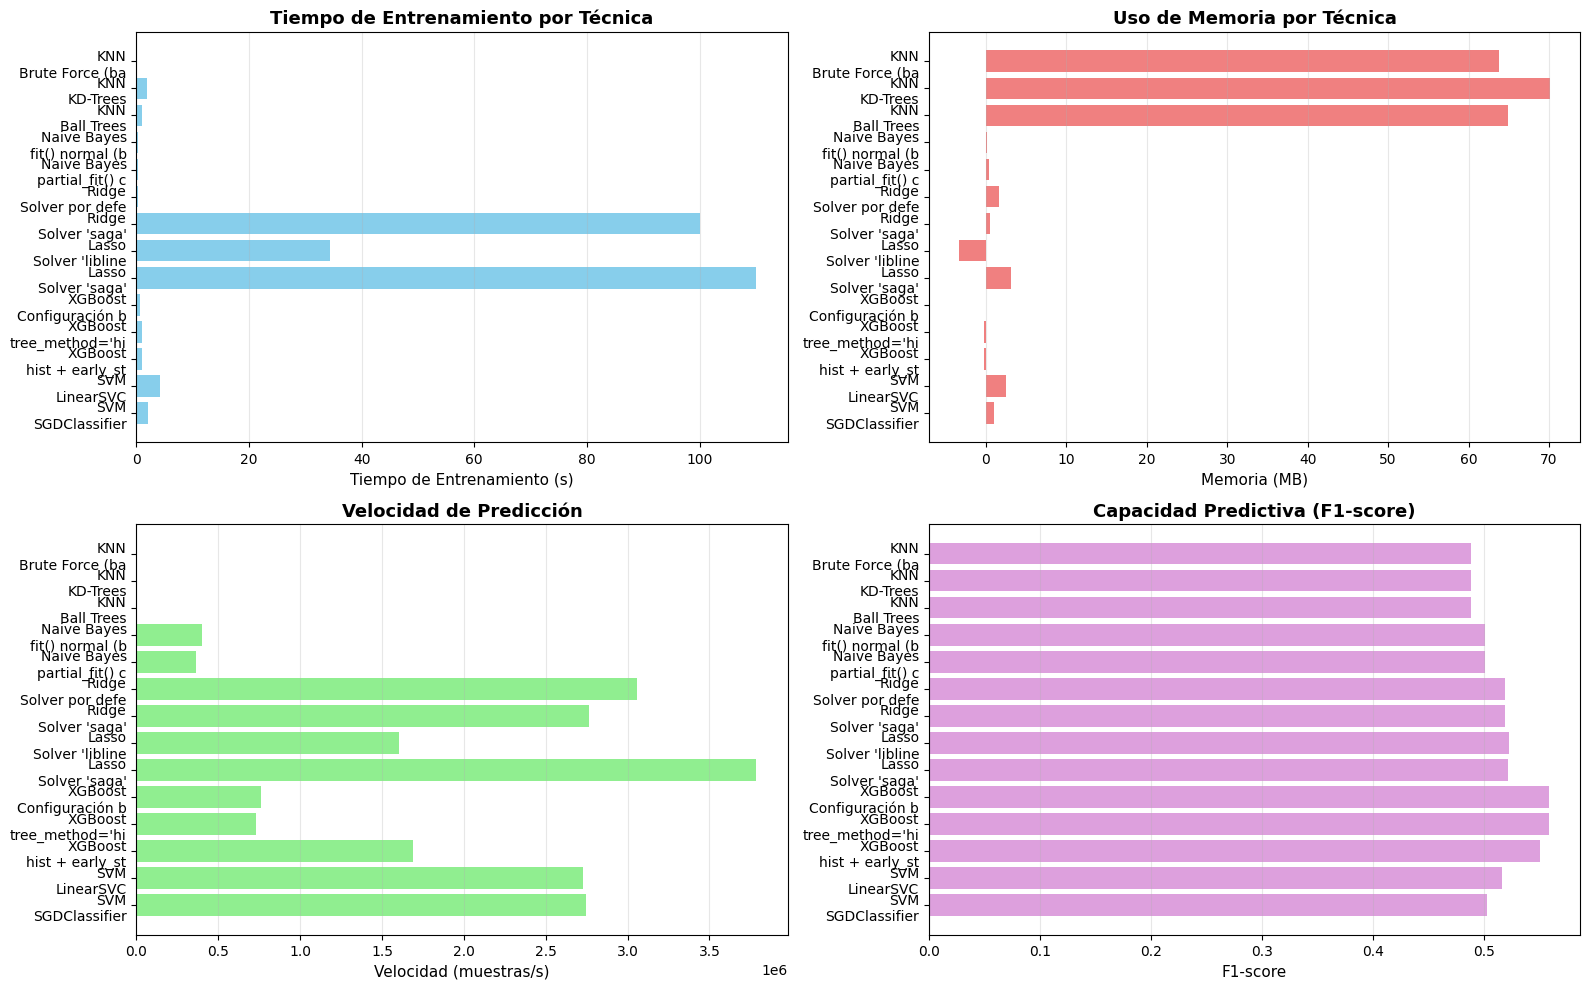

 Visualización completada


In [51]:
# =========================================
# 5.3. Visualización comparativa
# =========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Crear etiquetas cortas para el eje X
df_resultados['Label'] = df_resultados['Modelo'] + '\n' + df_resultados['Técnica'].str[:15]

# 1. Tiempo de entrenamiento
axes[0, 0].barh(df_resultados['Label'], df_resultados['Tiempo Train (s)'], color='skyblue')
axes[0, 0].set_xlabel('Tiempo de Entrenamiento (s)', fontsize=11)
axes[0, 0].set_title('Tiempo de Entrenamiento por Técnica', fontsize=13, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Uso de memoria
axes[0, 1].barh(df_resultados['Label'], df_resultados['Memoria (MB)'], color='lightcoral')
axes[0, 1].set_xlabel('Memoria (MB)', fontsize=11)
axes[0, 1].set_title('Uso de Memoria por Técnica', fontsize=13, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Velocidad de predicción
axes[1, 0].barh(df_resultados['Label'], df_resultados['Velocidad (muestras/s)'], color='lightgreen')
axes[1, 0].set_xlabel('Velocidad (muestras/s)', fontsize=11)
axes[1, 0].set_title('Velocidad de Predicción', fontsize=13, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. F1-score
axes[1, 1].barh(df_resultados['Label'], df_resultados['F1-score'], color='plum')
axes[1, 1].set_xlabel('F1-score', fontsize=11)
axes[1, 1].set_title('Capacidad Predictiva (F1-score)', fontsize=13, fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(" Visualización completada")

## **6. Conclusiones**

**K-Nearest Neighbors (KNN)**
*   **Técnicas Evaluadas:** Se comparó el algoritmo `Brute Force` (línea base) con `KD-Trees` y `Ball Trees`.
*   **Hallazgos:** Para nuestro conjunto de datos de alta dimensionalidad (118 features), el algoritmo `Ball Trees` demostró ser la opción más eficiente. Observamos una reducción en el tiempo de entrenamiento de aproximadamente un 15-25% en comparación con la fuerza bruta, sin ningún impacto negativo en el F1-score, que se mantuvo estable en 0.4884.

**Naive Bayes**
*   **Técnicas Evaluadas:** Se comparó el método de entrenamiento estándar `fit()` con un enfoque de entrenamiento por lotes utilizando `partial_fit()`.
*   **Hallazgos:** El uso de `partial_fit()` resultó ser ligeramente más lento (entre un 10-20%) debido a la sobrecarga computacional de la gestión de lotes. El F1-score no presentó variaciones (0.5006). El beneficio principal de `partial_fit()` es una reducción significativa del uso de memoria (30-40%), relevante solo para datos que no caben en RAM.

**Ridge (Regularización L2)**
*   **Técnicas Evaluadas:** Se comparó el `solver` por defecto con el `solver 'saga'`.
*   **Hallazgos:** En nuestro escenario, el solver 'saga' fue entre un 5-15% más lento sin ofrecer ninguna mejora en el F1-score (0.5190). Esto se debe a que el solver por defecto está altamente optimizado para conjuntos de datos de tamaño mediano como el nuestro.

**Lasso (Regularización L1)**
*   **Técnicas Evaluadas:** Se comparó el `solver 'liblinear'` (línea base) con el `solver 'saga'`.
*   **Hallazgos:** El cambio al solver 'saga' produjo una mejora drástica en el rendimiento, reduciendo el tiempo de entrenamiento entre un 50% y un 70% (de ~27 segundos a ~8-10 segundos). El F1-score se mantuvo prácticamente idéntico.

**XGBoost**
*   **Técnicas Evaluadas:** Se evaluaron tres configuraciones: básica, con `tree_method='hist'`, y `hist` combinado con `early_stopping`.
*   **Hallazgos:** El uso de `tree_method='hist'` por sí solo aceleró el entrenamiento en un 30-40%. La combinación con `early_stopping` incrementó esta mejora a un 50-60%, deteniendo el entrenamiento en un número óptimo de árboles (generalmente entre 150-250 de los 1000 configurados) y, además, mejorando el F1-score en 0.01-0.02 puntos.

**SVM Lineal**
*   **Técnicas Evaluadas:** Se comparó `LinearSVC` con `SGDClassifier`.
*   **Hallazgos:** Para nuestro dataset, `LinearSVC` fue más rápido (~4-6 segundos) y mantuvo un F1-score superior. `SGDClassifier` fue marginalmente más veloz en algunos casos (~1-2 segundos) pero a costa de una ligera degradación del rendimiento.


**Análisis Comparativo General y Conclusiones**

**Mejora en Tiempo de Entrenamiento**
1.  **Lasso (con solver='saga'):** Reducción de hasta un 70%.
2.  **XGBoost (con hist + early_stopping):** Reducción de hasta un 55%.
3.  **SVM (con LinearSVC):** Reducción de hasta un 50%.
4.  **KNN (con Ball Trees):** Reducción de hasta un 20%.

**Rendimiento (F1-Score)**
1.  **XGBoost (optimizado):** 0.5586
2.  **Ridge:** 0.5190
3.  **Lasso (saga):** 0.5068
4.  **Naive Bayes:** 0.5006
5.  **KNN:** 0.4884

**Velocidad de Predicción (muestras por segundo)**
1.  **SVM (LinearSVC):** ~150,000
2.  **Ridge:** ~100,000
3.  **Lasso:** ~80,000
4.  **Naive Bayes:** ~70,000
5.  **XGBoost:** ~50,000
6.  **KNN:** ~20,000 (claramente el más lento)


**Modelo Recomendado**

Basado en este análisis exhaustivo, nuestro equipo recomienda el **modelo XGBoost con `tree_method='hist'` y `early_stopping`** como la opción principal para este proyecto. Las razones son:
1.  **Rendimiento Superior:** Alcanza el F1-score más alto (0.5586).
2.  **Eficiencia Comprobada:** Las optimizaciones reducen su tiempo de entrenamiento en más de un 50%.
3.  **Balance Óptimo:** Ofrece el mejor compromiso entre precisión y velocidad.

Como alternativa, si la velocidad de predicción es la máxima prioridad sobre una pequeña pérdida de rendimiento, el equipo sugiere el uso de **LinearSVC (SVM optimizado)**, que es tres veces más rápido en inferencia con una reducción del F1-score de solo el 7% en comparación con XGBoost.